In [16]:
import numpy as np
from PIL import Image
from IPython.display import display
import requests

import cv2
import re
import json
import os

import torch
from transformers import GenerationConfig, pipeline, AutoModelForMultimodalLM, AutoProcessor

import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [17]:
# Set offline mode before importing Transformers.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


MODEL_PATH = (
    "/home/gridsan/manderson/ovdsat/"
    "weights/gemma-4-E4B-it"
)

# Load processor and model completely offline.
processor = AutoProcessor.from_pretrained(
    MODEL_PATH,
    local_files_only=True,
)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_PATH,
    local_files_only=True,
    device_map="auto",
    dtype=torch.float16,
    attn_implementation="sdpa",
)

model.eval()

print("Gemma 4 loaded fully offline.")

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Gemma 4 loaded fully offline.


In [11]:
# Helper functions.
def draw_bounding_box(
    image,
    coordinates,
    label,
    label_colors,
    width,
    height,
):
    y1, x1, y2, x2 = [
        float(coord) / 1000.0
        for coord in coordinates
    ]

    y1, x1, y2, x2 = map(
        round,
        (
            y1 * height,
            x1 * width,
            y2 * height,
            x2 * width,
        ),
    )

    color = label_colors.get(label)

    if color is None:
        color = np.random.randint(
            0,
            256,
            (3,),
        ).tolist()

        label_colors[label] = color

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    thickness = 2

    text_size, _ = cv2.getTextSize(
        label,
        font,
        font_scale,
        thickness,
    )

    text_width, text_height = text_size

    label_top = max(
        0,
        y1 - text_height - 10,
    )

    cv2.rectangle(
        image,
        (x1, label_top),
        (x1 + text_width + 8, y1),
        color,
        -1,
    )

    cv2.putText(
        image,
        label,
        (x1 + 4, y1 - 5),
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA,
    )

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        color,
        2,
    )

    return image


def extract_json(text):
    # First try a fenced JSON block.
    match = re.search(
        r"```json\s*(.*?)\s*```",
        text,
        re.DOTALL | re.IGNORECASE,
    )

    if match:
        return json.loads(match.group(1))

    # Fall back to the first JSON array.
    start = text.find("[")
    end = text.rfind("]")

    if start >= 0 and end > start:
        return json.loads(text[start:end + 1])

    raise ValueError(
        f"No JSON array found in response:\n{text}"
    )


def draw_results(text_content):
    try:
        data_list = extract_json(text_content)
    except Exception as error:
        print(f"Could not parse detections: {error}")
        return None

    output_img = np.array(input_image).copy()
    label_colors = {}

    width, height = input_image.size

    for item in data_list:
        if (
            "box_2d" not in item
            or "label" not in item
        ):
            continue

        output_img = draw_bounding_box(
            output_img,
            item["box_2d"],
            item["label"],
            label_colors,
            width,
            height,
        )

    return Image.fromarray(output_img)

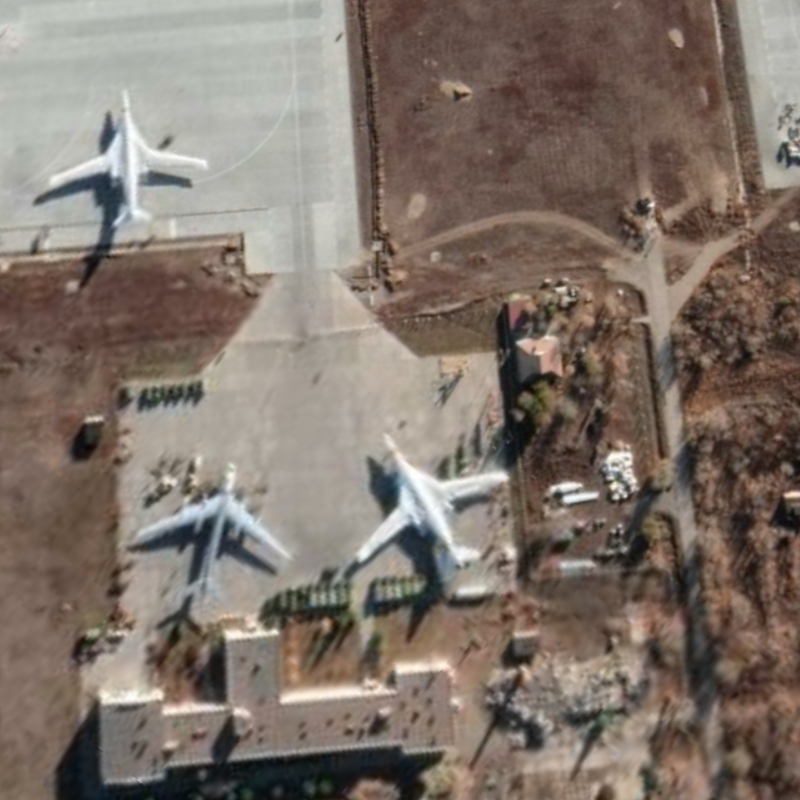

In [25]:
# Load image.
dataset = "mar"
img_num = "3402"

img_path = (
    f"/home/gridsan/manderson/ovdsat/data/"
    f"{dataset}/JPEGImages/{img_num}.jpg"
)

input_image = Image.open(img_path).convert("RGB")
display(input_image)

In [26]:
if dataset == 'dior':
    object_categories = [
        "airplane",
        "airport",
        "baseball field",
        "basketball court",
        "bridge",
        "chimney",
        "dam",
        "expressway service area",
        "expressway toll station",
        "golf field",
        "ground track field",
        "harbor",
        "overpass",
        "ship",
        "stadium",
        "storage tank",
        "tennis court",
        "train station",
        "vehicle",
        "windmill",
    ]
elif dataset == 'mar':
    # object_categories = [
    #     "B-1B",
    #     "B-52",
    #     "C-130",
    #     "C-17",
    #     "C-5",
    #     "E-3",
    #     "E-8",
    #     "F-15",
    #     "F-16",
    #     "F-22",
    #     "FA-18",
    #     "KC-1",
    #     "KC-135",
    #     "P-3C",
    #     "SU-24",
    #     "SU-34",
    #     "SU-35",
    #     "TU-160",
    #     "TU-22",
    #     "TU-95",
    # ]
    object_categories = [
        "B-1B aircraft",
        "B-52 aircraft",
        "C-130 aircraft",
        "C-17 aircraft",
        "C-5 aircraft",
        "E-3 aircraft",
        "E-8 aircraft",
        "F-15 aircraft",
        "F-16 aircraft",
        "F-22 aircraft",
        "FA-18 aircraft",
        "KC-1 aircraft",
        "KC-135 aircraft",
        "P-3C aircraft",
        "SU-24 aircraft",
        "SU-34 aircraft",
        "SU-35 aircraft",
        "TU-160 aircraft",
        "TU-22 aircraft",
        "TU-95 aircraft",
    ]

category_text = ", ".join(object_categories)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": input_image,
            },
            {
                "type": "text",
                "text": (
                    f"Detect every visible object belonging to these categories: "
                    f"{category_text}. "
                    "Return only a JSON array. "
                    "Each item must have exactly this format: "
                    '{"box_2d": [y1, x1, y2, x2], "label": "category"}. '
                    "The label must exactly match one of the provided categories. "
                    "Use integer coordinates normalized from 0 to 1000. "
                    "Return [] if no listed objects are visible."
                ),
            },
        ],
    }
]

RAW RESPONSE:
'[\n  {"box_2d": [117, 47, 275, 264], "label": "B-1B aircraft"},\n  {"box_2d": [562, 153, 723, 373], "label": "B-52 aircraft"},\n  {"box_2d": [545, 445, 723, 645], "label": "B-52 aircraft"}\n]<turn|>'

PARSED RESPONSE:
{'role': 'assistant', 'content': '[\n  {"box_2d": [117, 47, 275, 264], "label": "B-1B aircraft"},\n  {"box_2d": [562, 153, 723, 373], "label": "B-52 aircraft"},\n  {"box_2d": [545, 445, 723, 645], "label": "B-52 aircraft"}\n]'}

GENERATED TEXT:
'[\n  {"box_2d": [117, 47, 275, 264], "label": "B-1B aircraft"},\n  {"box_2d": [562, 153, 723, 373], "label": "B-52 aircraft"},\n  {"box_2d": [545, 445, 723, 645], "label": "B-52 aircraft"}\n]'


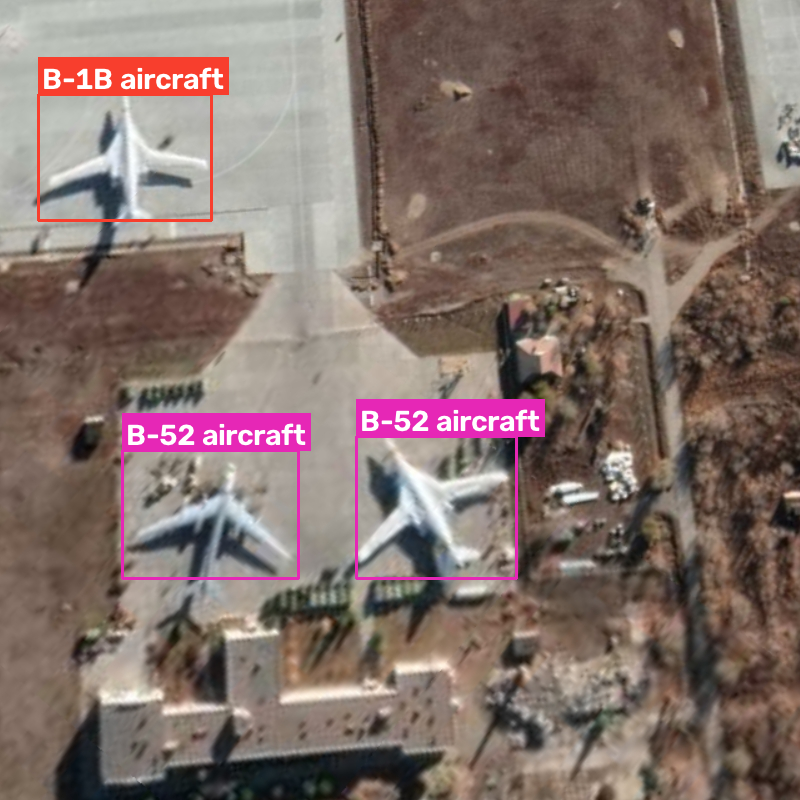

In [27]:
# Process the image and prompt.
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    enable_thinking=False,
    return_dict=True,
    return_tensors="pt",
)

input_device = model.get_input_embeddings().weight.device
inputs = inputs.to(input_device)

input_length = inputs["input_ids"].shape[-1]


# Generate deterministically.
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
        use_cache=True,
    )


# IMPORTANT:
# Keep Gemma 4's special response tokens here.
raw_response = processor.decode(
    generated_ids[0, input_length:],
    skip_special_tokens=False,
)

print("RAW RESPONSE:")
print(repr(raw_response))


# Parse Gemma 4's response wrapper.
parsed_response = processor.parse_response(raw_response)

print("\nPARSED RESPONSE:")
print(parsed_response)


# Extract the final text from the parsed response.
if isinstance(parsed_response, dict):
    generated_text = (
        parsed_response.get("content")
        or parsed_response.get("response")
        or parsed_response.get("answer")
        or ""
    )
else:
    generated_text = str(parsed_response)

print("\nGENERATED TEXT:")
print(repr(generated_text))


output_image = draw_results(generated_text)

if output_image is not None:
    display(output_image)

Ground truth: 3
Predictions:  3
mAP@0.5:      0.0000


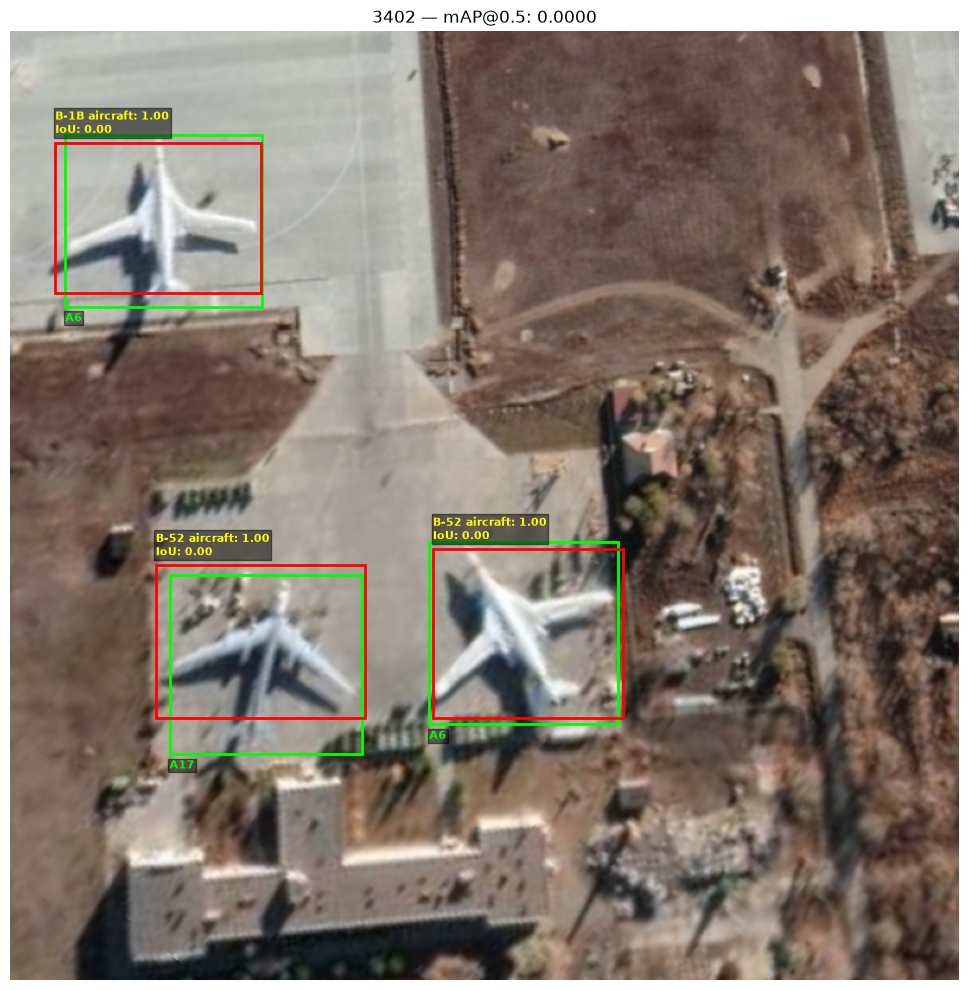

In [28]:
# Plot with ground truth

if dataset == 'dior':
    xml_path = f"/home/gridsan/manderson/ovdsat/data/dior/Annotations/{img_num}.xml"
elif dataset == 'mar': 
    xml_path = f"/home/gridsan/manderson/ovdsat/data/mar/Annotations/Horizontal Bounding Boxes/{img_num}.xml"
    

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return inter / (area1 + area2 - inter + 1e-16)


def compute_ap(recall, precision):
    mrec = np.concatenate(([0], recall, [1]))
    mpre = np.concatenate(([1], precision, [0]))
    mpre = np.maximum.accumulate(mpre[::-1])[::-1]

    indices = np.where(mrec[1:] != mrec[:-1])[0]

    return np.sum(
        (mrec[indices + 1] - mrec[indices])
        * mpre[indices + 1]
    )


# Load image
image = Image.open(img_path).convert("RGB")
width, height = image.size


# Load XML ground truth
root = ET.parse(xml_path).getroot()

ground_truth = []

for obj in root.findall("object"):
    label = obj.find("name").text.strip()
    box = obj.find("bndbox")

    ground_truth.append({
        "label": label,
        "box": np.array([
            float(box.find("xmin").text),
            float(box.find("ymin").text),
            float(box.find("xmax").text),
            float(box.find("ymax").text),
        ]),
    })


# Parse Gemma JSON
match = re.search(
    r"\[.*\]",
    generated_text,
    flags=re.DOTALL,
)

if match is None:
    raise ValueError(f"No JSON array found:\n{generated_text}")

raw_predictions = json.loads(match.group(0))

predictions = []

for pred in raw_predictions:
    y1, x1, y2, x2 = map(float, pred["box_2d"])

    predictions.append({
        "label": pred["label"].strip(),
        "score": float(pred.get("confidence", pred.get("score", 1.0))),
        "box": np.array([
            x1 / 1000 * width,
            y1 / 1000 * height,
            x2 / 1000 * width,
            y2 / 1000 * height,
        ]),
    })


# Compute best same-class IoU for every prediction
best_ious = []

for pred in predictions:
    matching_gt = [
        gt for gt in ground_truth
        if gt["label"].lower() == pred["label"].lower()
    ]

    best_ious.append(
        max((iou(pred["box"], gt["box"]) for gt in matching_gt), default=0.0)
    )


# Compute per-image AP@0.5
classes = sorted({
    gt["label"].lower()
    for gt in ground_truth
})

class_aps = []

for class_name in classes:
    gt_class = [
        gt for gt in ground_truth
        if gt["label"].lower() == class_name
    ]

    pred_class = sorted(
        [
            pred for pred in predictions
            if pred["label"].lower() == class_name
        ],
        key=lambda pred: pred["score"],
        reverse=True,
    )

    if not pred_class:
        class_aps.append(0.0)
        continue

    matched = np.zeros(len(gt_class), dtype=bool)
    tp = np.zeros(len(pred_class))
    fp = np.zeros(len(pred_class))

    for i, pred in enumerate(pred_class):
        ious = np.array([
            iou(pred["box"], gt["box"])
            for gt in gt_class
        ])

        best_gt = int(np.argmax(ious))
        best_iou = ious[best_gt]

        if best_iou >= 0.5 and not matched[best_gt]:
            tp[i] = 1
            matched[best_gt] = True
        else:
            fp[i] = 1

    tp = np.cumsum(tp)
    fp = np.cumsum(fp)

    recall = tp / len(gt_class)
    precision = tp / (tp + fp + 1e-16)

    class_aps.append(compute_ap(recall, precision))

image_map50 = np.mean(class_aps) if class_aps else 0.0

print(f"Ground truth: {len(ground_truth)}")
print(f"Predictions:  {len(predictions)}")
print(f"mAP@0.5:      {image_map50:.4f}")


# Plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image)


# Ground truth: green
for gt in ground_truth:
    x1, y1, x2, y2 = gt["box"]

    ax.add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            edgecolor="lime",
            facecolor="none",
            linewidth=2,
        )
    )

    ax.text(
        x1,
        min(y2 + 5, height - 1),
        gt["label"],
        color="lime",
        fontsize=8,
        weight="bold",
        verticalalignment="top",
        bbox=dict(facecolor="black", alpha=0.5, pad=1),
    )


# Predictions: red
for pred, best_iou in zip(predictions, best_ious):
    x1, y1, x2, y2 = pred["box"]

    ax.add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            edgecolor="red",
            facecolor="none",
            linewidth=2,
        )
    )

    ax.text(
        x1,
        max(y1 - 5, 0),
        f"{pred['label']}: {pred['score']:.2f}\nIoU: {best_iou:.2f}",
        color="yellow",
        fontsize=8,
        weight="bold",
        verticalalignment="bottom",
        bbox=dict(facecolor="black", alpha=0.5, pad=1),
    )


ax.set_title(f"{img_num} — mAP@0.5: {image_map50:.4f}")
ax.axis("off")
plt.tight_layout()
plt.show()